In [1]:
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
repo_root = next((c for c in [cwd, *cwd.parents] if (c / "utilities" / "functions.py").exists()), None)
if repo_root is None:
    raise FileNotFoundError("Could not find the repository root containing utilities/functions.py")
sys.path.append(str(repo_root))

import utilities.functions as functions

importlib.reload(functions)

data_root = repo_root / "ms0_5"
PROTEIN, MIN_POS, MAX_POS = 'RT', 39, 226

ALL_SEQ = functions.read_seq(str(data_root / "RT" / "data" / "rt.reduce4.seq"))
with open(str(data_root / "RT" / "data" / "rt.consensus.reduce4.seq")) as f:
    CONSENSUS = f.read().strip()
REDUX = functions.get_redu_dict(str(data_root / "RT" / "data" / "rt.reduce4.redux"), 0)


def build_J_matrix(j_file, min_position, max_position):
    """Dense coupling tensor, shape (L, L, 4, 5), indexed [p1, p2, aa_at_p1, aa_at_p2]."""
    J = np.load(j_file).astype(np.float32)
    L = max_position - min_position + 1
    Jm = np.zeros((L, L, 4, 5), dtype=np.float32)
    iu0, iu1 = np.triu_indices(L, 1)
    blocks = J.reshape(-1, 4, 4)
    assert blocks.shape[0] == iu0.size, "J.npy row count does not match the position range"
    Jm[iu0, iu1, :, :4] = blocks
    Jm[iu1, iu0, :, :4] = blocks.transpose(0, 2, 1)
    return Jm


J = build_J_matrix(str(data_root / "RT" / "data" / "J_RT.npy"), MIN_POS, MAX_POS)
L = MAX_POS - MIN_POS + 1
print(f"{PROTEIN}: {len(ALL_SEQ):,} sequences, {L} positions")

RT: 19,194 sequences, 188 positions


In [2]:
# ---------------------------------------------------------------------------
# Where the range of dE double comes from, term by term.
#
# For a pair (p1: wt1->mt1, p2: wt2->mt2), dE double splits EXACTLY into one term per
# background position q, plus the direct p1-p2 coupling:
#
#     dE double = sum_{q not in {p1,p2}} c(q)  +  [J(p1,p2,wt1,wt2) - J(p1,p2,mt1,mt2)]
#     c(q)      = [J(p1,q,wt1,s_q) - J(p1,q,mt1,s_q)] + [J(p2,q,wt2,s_q) - J(p2,q,mt2,s_q)]
#
# Every term is a DIFFERENCE of J values, and the only thing that changes from sequence to
# sequence is s_q, the residue the background happens to carry at q. So each position q can
# take just four values -- one per residue A/B/C/D -- and how much q moves dE double depends
# on two things:
#
#     lever   how far apart those four values are (a property of J alone)
#     usage   how often the alignment actually visits the residues that differ
#
# A position with a big lever that is never mutated contributes nothing to the range; a
# position that varies a lot but whose four J differences are equal contributes nothing
# either. Both have to be non-trivial, which is what CVAL and FREQ below separate.
# ---------------------------------------------------------------------------
_AA_CODE = np.full(256, 4, dtype=np.uint8)
for _i, _c in enumerate("ABCD"):
    _AA_CODE[ord(_c)] = _i


def encode_seqs(seq_list, min_pos, max_pos):
    Ln = max_pos - min_pos + 1
    N = len(seq_list)
    raw = np.frombuffer("".join(seq_list).encode(), dtype=np.uint8)
    assert raw.size == N * Ln, "all sequences must span exactly min_pos..max_pos"
    codes = _AA_CODE[raw.reshape(N, Ln)]
    onehot = np.zeros((N * Ln, 5), dtype=np.float32)
    onehot[np.arange(N * Ln), codes.ravel()] = 1.0
    return codes, onehot.reshape(N, Ln * 5)


def _site_energies(onehot, Jm, p, excluded):
    A = Jm[p].copy()
    A[list(excluded)] = 0.0
    return np.asarray(onehot @ A.transpose(0, 2, 1).reshape(-1, 4), dtype=np.float64)


def reduced_idx(pair):
    """'M41L-T215Y' -> (p1, p2, wt1, mt1, wt2, mt2) as 0-based position / residue indices."""
    a, b = functions.split_pairs(pair)
    wt1, pos1, mt1 = functions.split_pair(functions.unreduced_to_reduced(REDUX, a))
    wt2, pos2, mt2 = functions.split_pair(functions.unreduced_to_reduced(REDUX, b))
    return (pos1 - MIN_POS, pos2 - MIN_POS, "ABCD".index(wt1), "ABCD".index(mt1),
            "ABCD".index(wt2), "ABCD".index(mt2))


def decompose(pair, codes, onehot):
    """Per-position J-difference terms for one pair.

    Returns
        C      (N, L)  c(q) for every sequence and position -- the realized terms
        CVAL   (L, 4)  the four values c(q) can take, one per residue at q  (J only)
        de     (N,)    dE double, rebuilt from the terms and checked against the direct route
        direct scalar  the p1-p2 coupling difference, the one term with no background in it
    """
    p1, p2, wt1, mt1, wt2, mt2 = reduced_idx(pair)
    qs = np.arange(L)

    CVAL = ((J[p1][qs[:, None], wt1, np.arange(4)[None, :]]
             - J[p1][qs[:, None], mt1, np.arange(4)[None, :]])
            + (J[p2][qs[:, None], wt2, np.arange(4)[None, :]]
               - J[p2][qs[:, None], mt2, np.arange(4)[None, :]])).astype(np.float64)
    CVAL[[p1, p2]] = 0.0                      # the pair's own positions carry no background term

    C = CVAL[qs[None, :], codes]              # (N, L) realized terms
    direct = float(J[p1, p2, wt1, wt2] - J[p1, p2, mt1, mt2])

    S1 = _site_energies(onehot, J, p1, (p1, p2))
    S2 = _site_energies(onehot, J, p2, (p1, p2))
    J12 = J[p1, p2, :, :4].astype(np.float64)
    M = S1[:, :, None] + S2[:, None, :] + J12[None, :, :]
    de = M[:, wt1, wt2] - M[:, mt1, mt2]
    assert np.allclose(C.sum(axis=1) + direct, de, atol=1e-3), pair
    return C, CVAL, de, direct


print("machinery ready")

machinery ready


In [3]:
# =============================================================================
# Rank the top-dde DRM pairs by their dE double RANGE, then keep the extremes.
#
# top_20_DRM.txt holds the top-20 dde double pairs for each RT drug class (NRTI first, then
# NNRTI). For every pair that the model can handle we rebuild dE double over the whole
# alignment and measure its range the same way the earlier probe did -- 95th minus 5th
# percentile, which ignores a handful of outlier sequences.
#
# The question this notebook asks is the one the probe left open: a wide-range pair and a
# narrow-range pair are supposed to differ in HOW MANY background positions have leverage on
# them and WHERE those positions sit. So we take the 5 widest and the 5 narrowest and put
# their per-position sd profiles side by side, rows sorted by range.
# =============================================================================
N_EACH = 5
DRM_FILE = data_root / "RT" / "data" / "top_20_DRM.txt"

raw_pairs = []
for line in DRM_FILE.read_text().splitlines():
    line = line.strip()
    if line:
        raw_pairs.append('-'.join(tok.strip() for tok in line.split('-')))

CODES, ONEHOT = encode_seqs(ALL_SEQ, MIN_POS, MAX_POS)
POSITIONS = np.arange(MIN_POS, MAX_POS + 1)

STATS, skipped = {}, []
for pair in raw_pairs:
    try:
        p1, p2, *_ = reduced_idx(pair)
        if not (0 <= p1 < L and 0 <= p2 < L):
            raise ValueError(f"position outside {MIN_POS}-{MAX_POS}")
        C, CVAL, de, direct = decompose(pair, CODES, ONEHOT)
        lo, hi = np.percentile(de, [5, 95])
        STATS[pair] = dict(sd_q=C.std(axis=0), de=de, rng=hi - lo,
                           self_pos=(p1, p2), direct=direct)
    except Exception as exc:
        skipped.append((pair, str(exc)))

RANKED = pd.DataFrame(
    [{'pair': p, 'dE double range (95-5%)': d['rng'], 'sd(dE double)': d['de'].std(),
      'mean dE double': d['de'].mean(),
      'positions with sd(c) > 0.1': int((d['sd_q'] > 0.1).sum()),
      'largest position sd': d['sd_q'].max(),
      'strongest position': POSITIONS[int(np.argmax(d['sd_q']))]}
     for p, d in STATS.items()]
).sort_values('dE double range (95-5%)', ascending=False).reset_index(drop=True)

print(f"{len(STATS)} usable pairs out of {len(raw_pairs)} lines")
if skipped:
    print("skipped:", ', '.join(f'{p} ({why})' for p, why in skipped))
RANKED.round(3)

39 usable pairs out of 40 lines
skipped: V75I-I32L (substring not found)


,pair,dE double range (95-5%),sd(dE double),mean dE double,positions with sd(c) > 0.1,largest position sd,strongest position
0,L210W-T215Y,19.798,6.291,-0.700,38,2.448,41
1,M41L-T215Y,17.862,5.677,0.627,39,1.895,210
2,L210W-T215S,15.296,4.914,-2.796,38,1.878,41
3,M41L-T215F,14.916,4.812,-1.168,43,1.260,210
4,M41L-T215S,14.212,4.630,-1.870,38,1.709,210
5,K70R-K219Q,13.397,3.876,-3.945,29,2.342,67
6,D67N-K219Q,12.531,3.973,-2.982,33,1.975,70
7,D67N-K219E,11.900,3.813,-3.136,31,1.990,70
8,D67N-K70R,11.366,3.629,-2.516,24,2.141,219
9,K70R-K219E,10.787,3.378,-3.808,35,2.202,67


In [4]:
# The two extremes. WIDE keeps its descending order and NARROW is appended still descending,
# so the whole figure reads top-to-bottom as "most background-sensitive -> least".
WIDE = list(RANKED['pair'][:N_EACH])
NARROW = list(RANKED['pair'][-N_EACH:])
PAIRS = WIDE + NARROW
GROUP = {**{p: 'widest dE double range' for p in WIDE},
         **{p: 'narrowest dE double range' for p in NARROW}}

RNG = np.array([STATS[p]['rng'] for p in PAIRS])
SD = np.stack([STATS[p]['sd_q'] for p in PAIRS])
SD_TABLE = pd.DataFrame(SD, index=PAIRS, columns=POSITIONS)

for p in PAIRS:
    print(f"{GROUP[p]:<26} {p:<14} range {STATS[p]['rng']:6.2f}   "
          f"{int((STATS[p]['sd_q'] > 0.1).sum()):3d} positions with sd(c) > 0.1")

widest dE double range     L210W-T215Y    range  19.80    38 positions with sd(c) > 0.1
widest dE double range     M41L-T215Y     range  17.86    39 positions with sd(c) > 0.1
widest dE double range     L210W-T215S    range  15.30    38 positions with sd(c) > 0.1
widest dE double range     M41L-T215F     range  14.92    43 positions with sd(c) > 0.1
widest dE double range     M41L-T215S     range  14.21    38 positions with sd(c) > 0.1
narrowest dE double range  L100I-K103R    range   4.71    28 positions with sd(c) > 0.1
narrowest dE double range  A62V-V75I      range   4.67    27 positions with sd(c) > 0.1
narrowest dE double range  K101P-D192N    range   4.46    21 positions with sd(c) > 0.1
narrowest dE double range  V75I-F77L      range   4.38    23 positions with sd(c) > 0.1
narrowest dE double range  A62V-V57T      range   3.76    14 positions with sd(c) > 0.1


In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

SURFACE, INK, INK2, MUTED, GRID, BASE = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e6e5df', '#c3c2b7'

plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
                     'savefig.facecolor': SURFACE, 'font.size': 9, 'legend.frameon': False,
                     'axes.edgecolor': BASE, 'axes.linewidth': 0.7})

# Sequential, one hue, light -> dark: sd of c(q) is a magnitude, so darker red = a background
# position that swings this pair's dE double harder.
REDS = LinearSegmentedColormap.from_list(
    'jterm_reds', ['#fcfcfb', '#fbdcd0', '#f4a582', '#e2604a', '#bf2321', '#6d0f18'])
REDS.set_bad('#eeedea')          # the pair's own two positions carry no background term


def bare(ax, grid='y'):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(BASE)
    ax.tick_params(length=0, labelsize=8, colors=MUTED)
    ax.grid(axis=grid, color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    return ax

print('style ready')

style ready


In [6]:
# =============================================================================
# THE 0.05 TAIL of sd of c(q), taken across all the top-dde pairs at once.
#
# Pool every (pair, position) leverage value in the file -- 39 pairs x the positions that are
# not the pair's own two -- and that pooled distribution is what "normal" means here. The top
# 5% of it is the tail: a position sitting in it moves its pair's dE double more than 95% of
# all pair-position combinations do.
#
# This is a descriptive cut, not a hypothesis test. There is no null model and no p-value --
# 19,194 sequences make each sd essentially exact, so the only question is where a value
# falls in the distribution of all of them.
# =============================================================================
TAIL_FRAC = 0.05
ALL_PAIRS = list(STATS)

SD_ALL = np.stack([STATS[p]['sd_q'] for p in ALL_PAIRS])          # (P, L)

TESTABLE = np.ones(SD_ALL.shape, dtype=bool)                      # skip each pair's own positions
for i, p in enumerate(ALL_PAIRS):
    TESTABLE[i, list(STATS[p]['self_pos'])] = False

POOLED = SD_ALL[TESTABLE]
SD_TAIL = float(np.quantile(POOLED, 1 - TAIL_FRAC))
IN_TAIL = TESTABLE & (SD_ALL > SD_TAIL)

print(f"{len(ALL_PAIRS)} pairs x {L} positions -> {POOLED.size:,} pooled sd values")
print(f"median {np.median(POOLED):.4f}   90th {np.quantile(POOLED, .90):.3f}   "
      f"99th {np.quantile(POOLED, .99):.3f}   max {POOLED.max():.3f}")
print(f"top {TAIL_FRAC:.0%} tail starts at sd = {SD_TAIL:.3f}  "
      f"({IN_TAIL.sum():,} of {POOLED.size:,} cells)")

TAIL_BY_PAIR = pd.DataFrame({
    'pair': ALL_PAIRS,
    'positions in top 5% tail': IN_TAIL.sum(axis=1),
    'largest sd of c(q)': SD_ALL.max(axis=1),
    'dE double range': [STATS[p]['rng'] for p in ALL_PAIRS],
}).sort_values('positions in top 5% tail', ascending=False).reset_index(drop=True)
TAIL_BY_PAIR.round(3)

39 pairs x 188 positions -> 7,254 pooled sd values
median 0.0144   90th 0.152   99th 0.620   max 2.448
top 5% tail starts at sd = 0.246  (363 of 7,254 cells)


,pair,positions in top 5% tail,largest sd of c(q),dE double range
0,F116Y-Q151M,17,0.626,7.385
1,L210W-T215Y,17,2.448,19.798
2,M41L-T215Y,16,1.895,17.862
3,M41L-T215F,16,1.260,14.916
4,K70R-K219Q,13,2.342,13.397
5,L210W-T215S,12,1.878,15.296
6,K103N-P225H,12,0.815,6.905
7,E138A-G190E,12,0.713,5.728
8,L100I-K103S,12,0.943,5.866
9,K70R-K219E,11,2.202,10.787


saved jterm_sd_distribution_tail_RT.png / .pdf


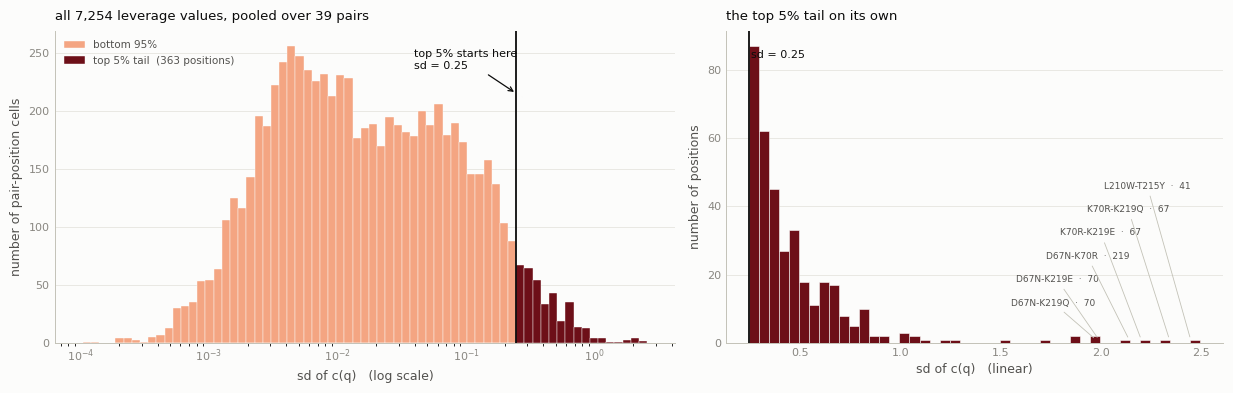

In [7]:
# =============================================================================
# FIGURE -- the distribution of sd of c(q), and what its top 5% looks like.
#
# LEFT: all 7,254 pooled values on a log axis, because they span four decades -- most
# positions sit around sd 0.01, i.e. they do essentially nothing to their pair's dE double.
# The shaded part is the top 5%, and the line is where it starts.
#
# RIGHT: the same tail on a linear axis, so its shape is readable. It is not a bump sitting
# out on its own -- it decays smoothly from the cut and thins out to a handful of positions
# past sd 1.5, which is where the TAM couplings sit.
# =============================================================================
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.4, 4.0),
                               gridspec_kw={'width_ratios': [1.25, 1]})

PALE, DEEP = '#f4a582', '#6d0f18'

# -- LEFT: the whole distribution, log x ---------------------------------------------------
bins = np.logspace(np.log10(max(POOLED.min(), 1e-5)), np.log10(POOLED.max()) + 0.02, 70)
axL.hist(POOLED[POOLED <= SD_TAIL], bins=bins, color=PALE, edgecolor=SURFACE, linewidth=0.3,
         label=f'bottom {1 - TAIL_FRAC:.0%}', zorder=3)
axL.hist(POOLED[POOLED > SD_TAIL], bins=bins, color=DEEP, edgecolor=SURFACE, linewidth=0.3,
         label=f'top {TAIL_FRAC:.0%} tail  ({IN_TAIL.sum():,} positions)', zorder=4)
axL.axvline(SD_TAIL, color=INK, lw=1.3, zorder=5)
axL.annotate(f'top {TAIL_FRAC:.0%} starts here\nsd = {SD_TAIL:.2f}',
             xy=(SD_TAIL, axL.get_ylim()[1] * 0.80),
             xytext=(SD_TAIL * 0.16, axL.get_ylim()[1] * 0.88), fontsize=8, color=INK,
             arrowprops=dict(arrowstyle='->', color=INK, lw=0.9))
axL.set_xscale('log')
axL.set_xlabel('sd of c(q)   (log scale)', color=INK2)
axL.set_ylabel('number of pair-position cells', color=INK2)
axL.set_title(f'all {POOLED.size:,} leverage values, pooled over {len(ALL_PAIRS)} pairs',
              fontsize=9.5, color=INK, loc='left', pad=8)
bare(axL)
axL.legend(fontsize=7.5, labelcolor=INK2, loc='upper left')

# -- RIGHT: the tail alone, linear x -------------------------------------------------------
tail_vals = POOLED[POOLED > SD_TAIL]
tbins = np.linspace(SD_TAIL, POOLED.max() * 1.02, 46)
axR.hist(tail_vals, bins=tbins, color=DEEP, edgecolor=SURFACE, linewidth=0.4, zorder=3)
axR.axvline(SD_TAIL, color=INK, lw=1.3, zorder=5)
axR.text(SD_TAIL * 1.04, axR.get_ylim()[1] * 0.94, f'sd = {SD_TAIL:.2f}', fontsize=8,
         color=INK, va='top')

# name the handful of positions right out at the end
_top = np.sort(np.argsort(POOLED)[::-1][:6])          # ascending sd: labels ladder up, no crossings
_top = _top[np.argsort(POOLED[_top])]
_pi, _qi = np.where(TESTABLE)
for r in _top:
    i, q = _pi[r], _qi[r]
    axR.annotate(f'{ALL_PAIRS[i]}  ·  {POSITIONS[q]}', xy=(SD_ALL[i, q], 1),
                 xytext=(SD_ALL[i, q], axR.get_ylim()[1] * (0.12 + 0.075 * list(_top).index(r))),
                 fontsize=6.5, color=INK2, ha='right',
                 arrowprops=dict(arrowstyle='-', color=BASE, lw=0.6))

axR.set_xlabel('sd of c(q)   (linear)', color=INK2)
axR.set_ylabel('number of positions', color=INK2)
axR.set_title(f'the top {TAIL_FRAC:.0%} tail on its own', fontsize=9.5, color=INK,
              loc='left', pad=8)
bare(axR)

fig.tight_layout()
fig.savefig('jterm_sd_distribution_tail_RT.png', dpi=400, bbox_inches='tight', pad_inches=0.03,
            facecolor=SURFACE)
fig.savefig('jterm_sd_distribution_tail_RT.pdf', bbox_inches='tight', pad_inches=0.03,
            facecolor=SURFACE)
print('saved jterm_sd_distribution_tail_RT.png / .pdf')
plt.show()

saved jterm_sd_heatmap_RT_wide_vs_narrow.png / .pdf   (vmax = 0.803 )


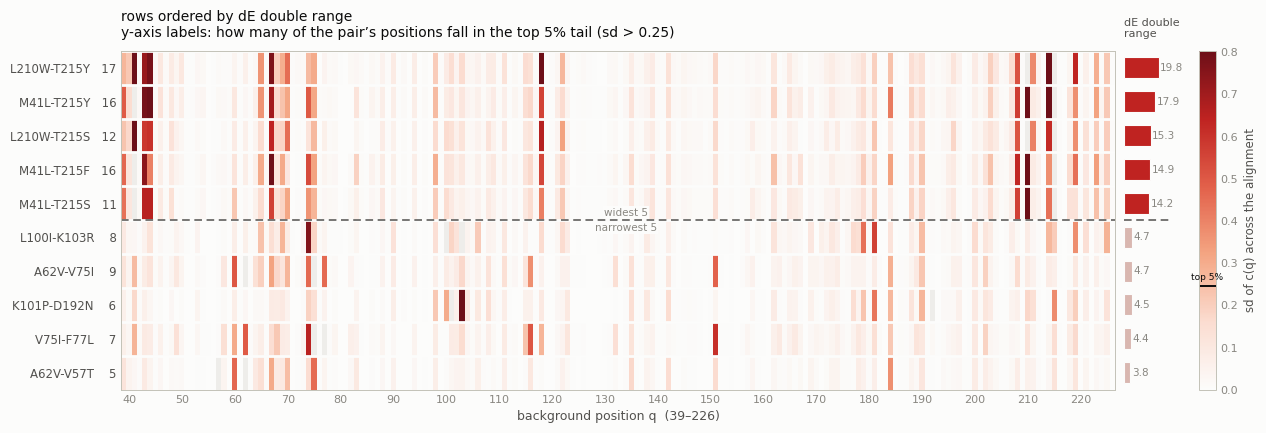

In [8]:
# =============================================================================
# THE HEAT MAP -- rows ordered by dE double range, widest 5 on top, narrowest 5 below, with
# the ranking drawn as a bar panel on the right so the sort is visible rather than implied.
#
# The tail is marked two ways. The colorbar carries a tick where the top 5% begins, so any
# cell darker than that tick is a tail position; and each row's y-axis label counts how many
# of its positions are in the tail, which is the per-pair version of the same thing.
# =============================================================================
ROW = {p: i for i, p in enumerate(ALL_PAIRS)}
TAIL_SEL = np.stack([IN_TAIL[ROW[p]] for p in PAIRS])

fig, (ax, axr) = plt.subplots(1, 2, figsize=(14.6, 4.4),
                              gridspec_kw={'width_ratios': [1, 0.13], 'wspace': 0.015})

vmax = float(np.percentile(SD[SD > 0], 99.5))
SD_PLOT = np.ma.masked_array(SD, mask=np.zeros_like(SD, dtype=bool))
for i, pair in enumerate(PAIRS):
    SD_PLOT.mask[i, list(STATS[pair]['self_pos'])] = True

im = ax.imshow(SD_PLOT, aspect='auto', cmap=REDS, vmin=0.0, vmax=vmax,
               interpolation='nearest',
               extent=[MIN_POS - 0.5, MAX_POS + 0.5, len(PAIRS) - 0.5, -0.5])

ylabels = [f'{p}   {TAIL_SEL[i].sum():>2d}' for i, p in enumerate(PAIRS)]
ax.set_yticks(range(len(PAIRS)), ylabels, fontsize=8.5, color=INK2)
xt = np.arange(40, MAX_POS + 1, 10)
ax.set_xticks(xt, [str(t) for t in xt], fontsize=8, color=MUTED)
ax.set_xlabel(f'background position q  ({MIN_POS}–{MAX_POS})', color=INK2)
ax.set_title('rows ordered by dE double range\n'
             f'y-axis labels: how many of the pair’s positions fall in the top '
             f'{TAIL_FRAC:.0%} tail (sd > {SD_TAIL:.2f})',
             fontsize=10, color=INK, loc='left', pad=10)

ax.set_yticks(np.arange(len(PAIRS)) - 0.5, minor=True)
ax.grid(which='minor', axis='y', color=SURFACE, linewidth=2.0)
ax.tick_params(length=0, which='both')
for s in ax.spines.values():
    s.set_color(BASE)

ax.axhline(N_EACH - 0.5, color=INK2, lw=1.1, ls=(0, (5, 3)))
for y, va, label in ((N_EACH - 0.58, 'bottom', f'widest {N_EACH}'),
                     (N_EACH - 0.42, 'top', f'narrowest {N_EACH}')):
    ax.text(134, y, label, fontsize=7.5, color=MUTED, va=va, ha='center',
            bbox=dict(facecolor=SURFACE, edgecolor='none', pad=0.8))

axr.barh(np.arange(len(PAIRS)), RNG, height=0.62,
         color=['#bf2321'] * N_EACH + ['#d9b7b0'] * N_EACH, edgecolor=SURFACE, linewidth=0.8)
for i, v in enumerate(RNG):
    axr.text(v + RNG.max() * 0.04, i, f'{v:.1f}', va='center', fontsize=7.5, color=MUTED)
axr.set_ylim(len(PAIRS) - 0.5, -0.5)
axr.set_xlim(0, RNG.max() * 1.32)
axr.set_yticks([]); axr.set_xticks([])
axr.set_title('dE double\nrange', fontsize=8, color=INK2, loc='left', pad=10)
axr.axhline(N_EACH - 0.5, color=INK2, lw=1.1, ls=(0, (5, 3)))
for s in axr.spines.values():
    s.set_visible(False)

cb = fig.colorbar(im, ax=axr, pad=0.22, fraction=0.42)
cb.set_label('sd of c(q) across the alignment', color=INK2, fontsize=8.5)
cb.ax.axhline(SD_TAIL, color=INK, lw=1.4)                       # where the top 5% begins
cb.ax.text(0.5, SD_TAIL * 1.04, f'top {TAIL_FRAC:.0%}', fontsize=6.5, color=INK,
           ha='center', va='bottom')
cb.outline.set_edgecolor(BASE)
cb.ax.tick_params(length=0, labelsize=8, colors=MUTED)

fig.savefig('jterm_sd_heatmap_RT_wide_vs_narrow.png', dpi=400, bbox_inches='tight',
            pad_inches=0.03, facecolor=SURFACE)
fig.savefig('jterm_sd_heatmap_RT_wide_vs_narrow.pdf', bbox_inches='tight', pad_inches=0.03,
            facecolor=SURFACE)
print('saved jterm_sd_heatmap_RT_wide_vs_narrow.png / .pdf   (vmax =', round(vmax, 3), ')')
plt.show()

saved jterm_top_positions_bars_RT_wide_vs_narrow.png / .pdf


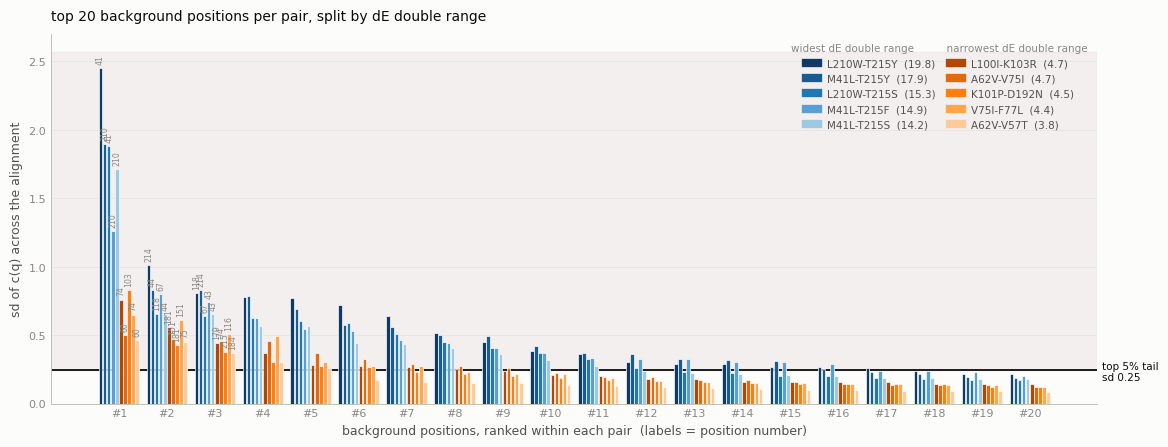

In [9]:
# =============================================================================
# THE RANKED-BAR VIEW -- the heat map's rows collapsed into their strongest positions, with
# the 0.05 tail drawn across the y axis.
#
# For every pair we take its top 10 background positions by sd of c(q) and plot them in rank
# order, so cluster #1 is each pair's single most influential position. Colour is the dE
# double range split -- blue for the widest 5, orange for the narrowest 5 -- shaded
# light-to-dark within each group by the pair's own range.
#
# The line is the top-5% cut from the distribution above, so "higher than normal" reads
# straight off the y axis. Nearly every bar here clears it, which is the expected result --
# these are each pair's ten best positions, so they should be in the tail -- and the useful
# reading is where each pair's curve finally drops back under it.
#
# The shape is the point, and it is a rank-#1 effect rather than a uniform one. Averaged
# within each group the wide/narrow ratio is 2.9x at rank #1 (1.84 vs 0.64) but only about
# 1.6-2.2x from rank #2 down, and the two decay curves stay roughly parallel after that --
# a narrow-range pair's best position (0.46-0.83) still beats a wide-range pair's 10th
# (0.31-0.42). So the wide-range pairs are not sensitive to the background everywhere; they
# each own one dominant position -- 41 or 210, the other TAM site -- that no narrow-range
# pair has an equivalent of, and that single position is where most of their range comes from.
# =============================================================================
TOPN_BAR = 20

WIDE_SHADES   = ['#0d3b66', '#175d92', '#1f77b4', '#57a0d3', '#9ecae1']
NARROW_SHADES = ['#b34700', '#e06a10', '#ff7f0e', '#ffa64d', '#ffcb99']
BAR_COLOR = {**{p: WIDE_SHADES[i] for i, p in enumerate(WIDE)},
             **{p: NARROW_SHADES[i] for i, p in enumerate(NARROW)}}

fig, ax = plt.subplots(figsize=(13.5, 4.8))

width = 0.085
offsets = (np.arange(len(PAIRS)) - (len(PAIRS) - 1) / 2) * width

for k, pair in enumerate(PAIRS):
    sd = SD[k]
    order = np.argsort(-sd)[:TOPN_BAR]
    x = np.arange(TOPN_BAR) + offsets[k]
    ax.bar(x, sd[order], width=width * 0.88, color=BAR_COLOR[pair],
           edgecolor=SURFACE, linewidth=0.5, zorder=3)
    for j in range(3):
        q = order[j]
        ax.text(x[j], sd[q] + 0.03, str(POSITIONS[q]), ha='center', va='bottom',
                fontsize=5.6, color=MUTED, rotation=90)

# -- the 0.05 tail, marked on the y axis ---------------------------------------------------
ax.axhline(SD_TAIL, color=INK, lw=1.3, zorder=2)
ax.axhspan(SD_TAIL, ax.get_ylim()[1], color=DEEP, alpha=0.05, zorder=0)

axt = ax.twinx()
axt.set_ylim(ax.get_ylim())
axt.set_yticks([SD_TAIL], [f'top {TAIL_FRAC:.0%} tail\nsd {SD_TAIL:.2f}'])
axt.get_yticklabels()[0].set(color=INK, fontsize=7.5)
axt.tick_params(length=0)
for sp in axt.spines.values():
    sp.set_visible(False)

ax.set_xticks(range(TOPN_BAR), [f'#{i + 1}' for i in range(TOPN_BAR)], fontsize=8.5)
ax.set_xlabel('background positions, ranked within each pair  (labels = position number)',
              color=INK2)
ax.set_ylabel('sd of c(q) across the alignment', color=INK2)
ax.set_title(f'top {TOPN_BAR} background positions per pair, split by dE double range',
             fontsize=10, color=INK, loc='left', pad=10)
bare(ax)

handles = [Line2D([], [], color=BAR_COLOR[p], lw=6,
                  label=f'{p}  ({STATS[p]["rng"]:.1f})') for p in PAIRS]
leg = ax.legend(handles=handles, ncol=2, fontsize=7.5, labelcolor=INK2, loc='upper right',
                handlelength=1.2, columnspacing=1.4,
                title='widest dE double range          narrowest dE double range',
                title_fontsize=7.5)
leg.get_title().set_color(MUTED)

fig.savefig('jterm_top_positions_bars_RT_wide_vs_narrow.png', dpi=400, bbox_inches='tight',
            pad_inches=0.03, facecolor=SURFACE)
fig.savefig('jterm_top_positions_bars_RT_wide_vs_narrow.pdf', bbox_inches='tight',
            pad_inches=0.03, facecolor=SURFACE)
print('saved jterm_top_positions_bars_RT_wide_vs_narrow.png / .pdf')
plt.show()

In [10]:
# The same contrast without colour: for each pair, its strongest background positions, with
# the ones in the top 5% tail flagged.
TOPN = 8
readout = pd.DataFrame(
    {pair: [f'{POSITIONS[q]} ({SD[i, q]:.2f}){"*" if TAIL_SEL[i, q] else ""}'
            for q in np.argsort(-SD[i])[:TOPN]]
     for i, pair in enumerate(PAIRS)},
    index=[f'#{k + 1}' for k in range(TOPN)]).T
readout.insert(0, 'group', [GROUP[p] for p in PAIRS])
readout.insert(1, 'dE double range', np.round(RNG, 2))
readout.insert(2, 'in tail', TAIL_SEL.sum(axis=1))
readout.index.name = 'pair'

group_stats = pd.DataFrame([
    {'group': g,
     'pairs': int((np.array([GROUP[p] for p in PAIRS]) == g).sum()),
     'median dE double range': np.median([STATS[p]['rng'] for p in PAIRS if GROUP[p] == g]),
     'median positions in top 5% tail':
         np.median([IN_TAIL[ROW[p]].sum() for p in PAIRS if GROUP[p] == g]),
     'median largest position sd':
         np.median([STATS[p]['sd_q'].max() for p in PAIRS if GROUP[p] == g]),
     'median total sd (sum over q)':
         np.median([STATS[p]['sd_q'].sum() for p in PAIRS if GROUP[p] == g])}
    for g in ('widest dE double range', 'narrowest dE double range')])

SD_TABLE.to_csv('jterm_sd_by_position_RT_wide_vs_narrow.csv')
RANKED.to_csv('jterm_de_range_ranking_RT.csv', index=False)
TAIL_BY_PAIR.to_csv('jterm_tail_counts_RT.csv', index=False)
print('saved jterm_sd_by_position_RT_wide_vs_narrow.csv, jterm_de_range_ranking_RT.csv,'
      ' jterm_tail_counts_RT.csv')
display(group_stats.round(2))
readout

saved jterm_sd_by_position_RT_wide_vs_narrow.csv, jterm_de_range_ranking_RT.csv, jterm_tail_counts_RT.csv


,group,pairs,median dE double range,median positions in top 5% tail,median largest position sd,median total sd (sum over q)
0,widest dE double range,5,15.30,16.0,1.88,15.53
1,narrowest dE double range,5,4.46,7.0,0.65,9.26


,group,dE double range,in tail,#1,#2,#3,#4,#5,#6,#7,#8
pair,,,,,,,,,,,
L210W-T215Y,widest dE double range,19.80,17,41 (2.45)*,214 (1.01)*,118 (0.80)*,44 (0.78)*,67 (0.77)*,43 (0.72)*,219 (0.64)*,208 (0.52)*
M41L-T215Y,widest dE double range,17.86,16,210 (1.89)*,44 (0.83)*,214 (0.83)*,43 (0.78)*,67 (0.69)*,208 (0.57)*,118 (0.56)*,74 (0.50)*
L210W-T215S,widest dE double range,15.30,12,41 (1.88)*,118 (0.66)*,67 (0.64)*,214 (0.62)*,44 (0.60)*,43 (0.59)*,208 (0.51)*,70 (0.45)*
M41L-T215F,widest dE double range,14.92,16,210 (1.26)*,67 (0.80)*,43 (0.74)*,208 (0.63)*,118 (0.55)*,74 (0.53)*,39 (0.47)*,219 (0.44)*
M41L-T215S,widest dE double range,14.21,11,210 (1.71)*,44 (0.65)*,43 (0.65)*,208 (0.56)*,67 (0.56)*,39 (0.44)*,214 (0.44)*,118 (0.41)*
L100I-K103R,narrowest dE double range,4.71,8,74 (0.76)*,181 (0.56)*,179 (0.44)*,219 (0.37)*,225 (0.28)*,69 (0.27)*,214 (0.26)*,190 (0.25)*
A62V-V75I,narrowest dE double range,4.67,9,60 (0.50)*,151 (0.48)*,74 (0.46)*,77 (0.46)*,116 (0.37)*,67 (0.32)*,184 (0.29)*,70 (0.27)*
K101P-D192N,narrowest dE double range,4.46,6,103 (0.83)*,181 (0.43)*,215 (0.38)*,100 (0.30)*,190 (0.27)*,184 (0.27)*,179 (0.23),98 (0.22)
V75I-F77L,narrowest dE double range,4.38,7,74 (0.65)*,151 (0.61)*,116 (0.51)*,62 (0.49)*,60 (0.30)*,41 (0.28)*,118 (0.27)*,115 (0.23)
